# EDA

## 1. Importing libaries

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import re
from matplotlib import pyplot as plt
import string
import nltk
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud
from nltk.util import ngrams
import warnings

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Loading the Input Dataset

The dataset used in this project is sourced from **GitHub**. This specific version has been pre-processed and consolidated into a single `.csv` file (the original dataset consisted of numerous individual `.txt` files).

* **Dataset Source:** [enron_spam_data](hhttps://github.com/MWiechmann/enron_spam_data/blob/master/enron_spam_data.zip)

* **Context of dataset:** In 2001, the American energy giant Enron went bankrupt due to one of the biggest financial fraud scandals in history. During the investigation, the U.S. Federal Energy Regulatory Commission (FERC) seized and publicly released Enron's entire email server database. After being seized, Enron's servers primarily contained work emails, lacking a neatly labeled "Spam" folder suitable for machine learning.In 2006, researchers (V. Metsis, I. Androutsopoulos, G. Paliouras) decided to create a standard dataset. They took Enron's Ham emails and then injected real spam collected from spam trap systems (Honeypot), SpamAssassin, and other web sources. In result, six datasets (from Enron 1 to Enron 6) strike a balance between `HAM` and `SPAM`. MWiechmann's archive on GitHub is a consolidated version converted to a .csv file for easier use from that famous research project.

Next, we will proceed with the Exploratory Data Analysis (EDA) to understand the underlying structure of the dataset

In [3]:
enron_dataset = pd.read_csv('./data/raw/enron_spam_data.csv')

## 3. Data Overview
### 3.1. Basic Information of Raw Dataset

We will investigate:
- Amount of samples in dataset
- Amount of null values/samples
- Labels distribution

Here is a summary of the basic information regarding the raw dataset:

- **Total samples:** *33,716* records.
- **Total features:** *5* features (columns).
- **Data types:** Except for the **Message ID** which is of type `int64`, all remaining features are of type `object` (string).
- **Missing values:** Observing the non-null counts in the **Subject** and **Message** columns, we can see that they are lower than the total number of samples. This indicates the presence of missing (null) data in these specific features.

In [4]:
enron_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 33716 entries, 0 to 33715
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Message ID  33716 non-null  int64
 1   Subject     33427 non-null  str  
 2   Message     33345 non-null  str  
 3   Spam/Ham    33716 non-null  str  
 4   Date        33716 non-null  str  
dtypes: int64(1), str(4)
memory usage: 1.3 MB


### 3.2. SPAM / HAM distributions

Visualizing the class distribution via a bar chart reveals that the number of `SPAM samples` **slightly exceeds** that of `HAM`. However, this difference is *negligible* (approximately **1.85%**). 

Therefore, the raw dataset is considered well-balanced between the two classes.

Spam/Ham
spam    17171
ham     16545
Name: count, dtype: int64


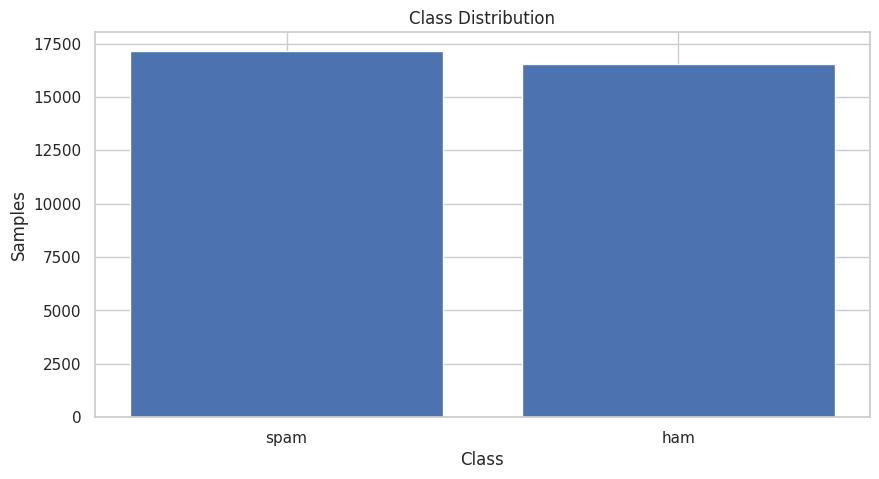

In [5]:
# Plotting bar chart, using Matplotlib library
colors = sns.color_palette(palette='bright')
# Counting the frequency of SPAM/HAM labels to visualize the bar chart
label_counts = enron_dataset['Spam/Ham'].value_counts()
labels = ['spam','ham']

print(label_counts)

# Setting figure size
plt.figure(figsize=(10, 5))

# Creating bar chart
plt.bar(labels, label_counts)

# Adding title and labels
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Samples")

plt.show()

## 4. Missing Data Analysis

Investigating and analyzing the patterns of missing values (NaN) and handling them systematically:

* **Detect missing values** across the dataset.
* **Calculate the missing data ratio for each feature:**
    * If the **Message** feature is null/empty string, drop the record entirely, as an email without body content provides no predictive value.
    * If the **Subject** feature is null/empty string, do not drop it; instead, impute the missing values with the string `"No Subject"`.
* **Count the total number of emails** that are missing both the **Subject** and the **Message** features (null or empty string).
* **Filter the subset of emails** with a missing **Subject**. Then, calculate the Spam/Ham distribution ratio within this specific subset.
* **Calculate the proportion of missing Subjects** within each individual class (Spam vs. Ham).
* **Calculate the proportion of emails using uppercase letters** in the **Subject** line for both Spam and Ham classes.
* **Calculate the rate of excessive special character (punctuation) usage** in the **Subject** line for both Spam and Ham classes.

### 4.1. Percentage of missing Features in Dataset

- Calculate the **percentage** of `missing Message feature only / total samples`.
- Calculate the **percentage** of `missing Subject feature only / total samples`.
- Calculate the **percentage** of `missing both features / total samples`.


In [6]:
msg_missing = enron_dataset['Message'].fillna('').str.strip() == ''
sub_missing = enron_dataset['Subject'].fillna('').str.strip() == ''

missing_conditions = {
    'Subject Only': sub_missing & ~msg_missing,
    'Message Only': msg_missing & ~sub_missing,
    'Both Subject and Message': sub_missing & msg_missing
}

total_len = len(enron_dataset)
counts = {k: v.sum() for k, v in missing_conditions.items()}
pcts = {k: (v / total_len) * 100 for k, v in counts.items()}

missing_df = pd.DataFrame({
    'Missing Count': counts,
    'Missing Percentage (%)': pcts
})

print(missing_df[missing_df['Missing Count'] > 0])

                          Missing Count  Missing Percentage (%)
Subject Only                        238                0.705896
Message Only                        320                0.949104
Both Subject and Message             51                0.151263


In [7]:
warnings.filterwarnings('ignore')

- Missing `Message` Feature samples: 289
- Missing `Subject` Feature samples: 371
- Missing both `Subject` and `Message` Features samples: 51

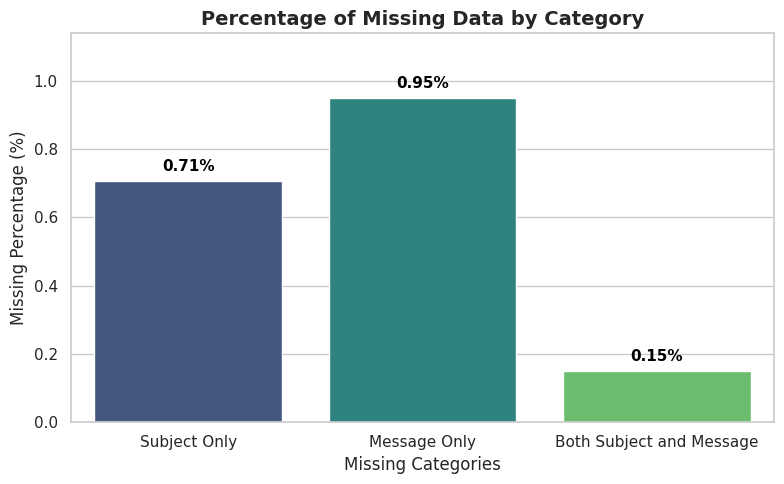

In [8]:
missing_features_df = missing_df[missing_df['Missing Count'] > 0]

if not missing_features_df.empty:
    plt.figure(figsize=(8, 5))
    
    ax = sns.barplot(
        x=missing_features_df.index, 
        y=missing_features_df['Missing Percentage (%)'], 
        hue=missing_features_df.index,
        palette="viridis", 
        legend=False
    )
    
    plt.title('Percentage of Missing Data by Category', fontsize=14, fontweight='bold')
    plt.ylabel('Missing Percentage (%)', fontsize=12)
    plt.xlabel('Missing Categories', fontsize=12)
    
    plt.ylim(0, missing_features_df['Missing Percentage (%)'].max() * 1.2)
    
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', 
                    fontsize=11, fontweight='bold', color='black', 
                    xytext=(0, 5), textcoords='offset points')
    
    plt.tight_layout()
    plt.show()
else:
    print("There are not any datas to visualize")

## 4.2. Labels Distribution in Missing Features Samples

Delving deeper into the 289 emails missing a **Subject**, the distribution chart reveals a striking pattern: **100% (289/289)** of emails without a subject line are **Spam**. There is not a single legitimate work email (**Ham**) that forgets to include a subject. 

This is likely because, in a professional corporate environment (such as the context of the Enron dataset), employees strictly adhere to the rule of providing clear subject lines for business communication. Conversely, scammers often utilize automated tools (bots) to broadcast bulk spam; they either neglect to fill in the subject or intentionally leave it blank to pique curiosity, tricking users into opening the email to view the content.

Based on the insight above, we decided to implement specific handling strategies for each feature as follows:

* **For the `Message` column:** It is mandatory to drop all 371 of these emails. A data sample without body text is completely worthless for text classification. Retaining these empty records would only introduce noise and degrade the model's overall accuracy.

* **For the `Subject` column:** Do not drop these records. Instead, impute the missing values with a fixed text string: `"No Subject"`. Since the "missing subject" characteristic has been empirically proven to be a distinct behavior of Spam, imputing it allows us to capture this pattern. In the subsequent vectorization step, the TF-IDF algorithm will count and assign a very high weight to the specific phrase `"No Subject"`. Consequently, the model will automatically deduce the underlying rule: *If an email contains the phrase "No Subject", there is a remarkably high probability that it is Spam.*

There are 289 email that missed Subject


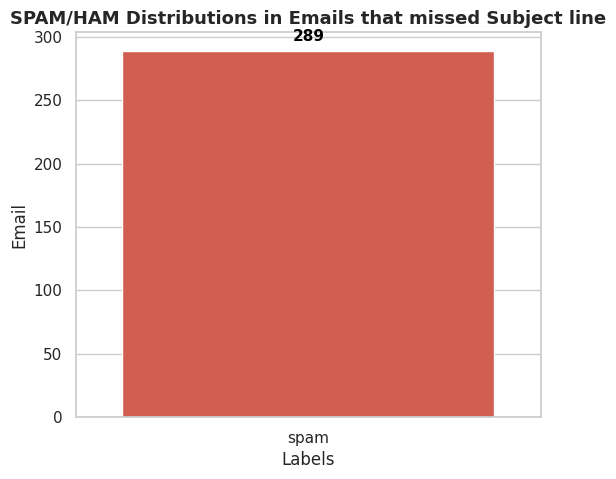

In [9]:
missing_subject_df = enron_dataset[enron_dataset['Subject'].isnull()]

if not missing_subject_df.empty:
    print(f"There are {len(missing_subject_df)} email that missed Subject")
    
    plt.figure(figsize=(6, 5))
    ax2 = sns.countplot(data=missing_subject_df, x='Spam/Ham', palette={'ham': '#2ecc71', 'spam': '#e74c3c'},legend=False)
    plt.title('SPAM/HAM Distributions in Emails that missed Subject line', fontsize=13, fontweight='bold')
    plt.ylabel('Email', fontsize=12)
    plt.xlabel('Labels', fontsize=12)
    
    for p in ax2.patches:
        ax2.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=11, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')
    plt.show()

Next, we will drop rows that missed `Message` feature

In [10]:
initial_rows = len(enron_dataset)

enron_dataset = enron_dataset.dropna(subset=['Message'])
print(f"[-] Deleted {initial_rows - len(enron_dataset)} mails that missed 'Message'")

enron_dataset.loc[:, 'Subject'] = enron_dataset['Subject'].fillna('No Subject')
print("[+] Filled 'No Subject' for emails that missed 'Subject'")

[-] Deleted 371 mails that missed 'Message'
[+] Filled 'No Subject' for emails that missed 'Subject'


After dropping and imputing the missing values for the `Message` and `Subject` features, we performed double check to ensure data integrity:

* **Dataset Size Verification:** After removing the rows with missing `Message` content, the dataset size was reduced to **33,345** samples (a decrease of 371 records from the raw dataset count).
* **Null Value Elimination:** Critical features such as `Message` and `Subject` no longer contain any null or empty values (following the target imputation on the subject line). The cleaned dataset is now fully prepared for the next stage.

In [11]:
enron_dataset.info()

<class 'pandas.DataFrame'>
Index: 33345 entries, 1 to 33715
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Message ID  33345 non-null  int64
 1   Subject     33345 non-null  str  
 2   Message     33345 non-null  str  
 3   Spam/Ham    33345 non-null  str  
 4   Date        33345 non-null  str  
dtypes: int64(1), str(4)
memory usage: 1.5 MB


### 4.3. Subject line Analysis

- **Missing Subject Ratio**: The rate of missing subjects in the Spam class is 1.41%, whereas it is an absolute 0.00% in the Ham class. Enron corporation employees adhered to corporate communication protocols very strictly; 100% of their emails included a subject line. Conversely, a portion of spam, often dispatched by automated bots or lazy scammers, left this field blank.

- **Uppercase Letter Usage**: The boxplot indicates that Ham emails have no outliers, meaning employees capitalized text appropriately and conventionally. In contrast, Spam displays a cluster of outliers with capitalization rates spiking from *2.5% - 17.5%*. This suggests that scammers frequently utilize the CAPS LOCK key to craft "shouting" subject lines designed to grab immediate attention (e.g., **URGENT**, **FREE MONEY**). This grammatical indiscipline is a highly potent indicator for identifying Spam.

- **Special Character Usage**: `HAM emails` occasionally utilize special characters (ranging from 1 to 8 symbols) for legitimate business purposes (e.g., the `?` for questions, `$` for quotes). However, the main body (the box) of the Spam distribution is noticeably elevated, with outlier tails extending from 3 to over 12 special characters, indicating a heavy abuse of these symbols.

In [12]:
# Calculate the percentage of 'No Subject' according to Spam labels
no_subject_df = enron_dataset[enron_dataset['Subject'] == 'No Subject']
no_subject_counts = no_subject_df['Spam/Ham'].value_counts()
total_spam = len(enron_dataset[enron_dataset['Spam/Ham'] == 'spam'])
total_ham = len(enron_dataset[enron_dataset['Spam/Ham'] == 'ham'])


In [13]:
spam_no_subj_rate = (no_subject_counts.get('spam', 0) / total_spam) * 100 if total_spam > 0 else 0
ham_no_subj_rate = (no_subject_counts.get('ham', 0) / total_ham) * 100 if total_ham > 0 else 0

rate_df = pd.DataFrame({
    'Labels': ['Spam', 'Ham'],
    'No Subject Percentages (%)': [spam_no_subj_rate, ham_no_subj_rate]
})

In [14]:
def uppercase_ratio(text: str)->float:

    """
    Calculate the uppercase letter ratio in given text
    
    Return 0 if in Subject Line is Empty or `No Subject`
    """

    if text == 'No Subject' or pd.isna(text): 
        return 0
    text_str = str(text)
    letters = sum(1 for c in text_str if c.isalpha())
    if letters == 0: 
        return 0
    uppers = sum(1 for c in text_str if c.isupper())
    return uppers / letters

In [15]:
def suspicious_symbol_count(text):

    """
    Counting the amount of suspicious symbols such as: `!`;`?`;`$`;`%`;`*`
    
    Return 0 if in text is Empty or `No Subject`
    """


    if text == 'No Subject' or pd.isna(text): 
        return 0
    return len(re.findall(r'[!?$%*]', str(text)))

In [16]:
enron_dataset['Subject_Upper_Ratio'] = enron_dataset['Subject'].apply(uppercase_ratio)
enron_dataset['Subject_Suspicious_Symbols'] = enron_dataset['Subject'].apply(suspicious_symbol_count)

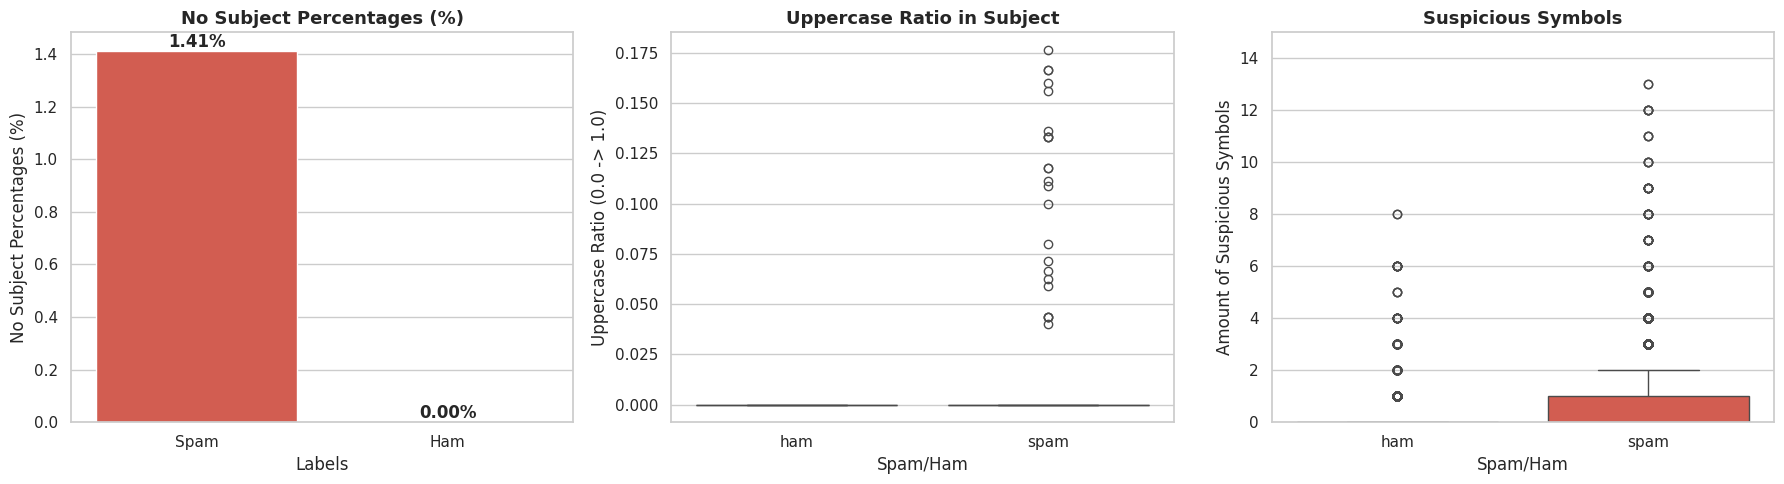

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=rate_df, x='Labels', y='No Subject Percentages (%)', palette={'Ham': '#2ecc71', 'Spam': '#e74c3c'}, ax=axes[0])
axes[0].set_title('No Subject Percentages (%)', fontsize=13, fontweight='bold')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontweight='bold')

sns.boxplot(data=enron_dataset[enron_dataset['Subject'] != 'No Subject'], 
            x='Spam/Ham', y='Subject_Upper_Ratio', palette={'ham': '#2ecc71', 'spam': '#e74c3c'}, ax=axes[1])
axes[1].set_title('Uppercase Ratio in Subject', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Uppercase Ratio (0.0 -> 1.0)')

sns.boxplot(data=enron_dataset[enron_dataset['Subject'] != 'No Subject'], 
            x='Spam/Ham', y='Subject_Suspicious_Symbols', palette={'ham': '#2ecc71', 'spam': '#e74c3c'}, ax=axes[2])
axes[2].set_title('Suspicious Symbols', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Amount of Suspicious Symbols')
axes[2].set_ylim(0, 15)

plt.tight_layout()
plt.show()

In [18]:
enron_dataset.drop(columns=['Subject_Upper_Ratio', 'Subject_Suspicious_Symbols'], inplace=True)

## 5. Univariate Analysis

**Objective:** To explore the distribution characteristics of each variable independently across the entire dataset.

* **Feature Engineering:** Transform raw text `Message` into quantifiable numerical metrics by engineering two new features: `Message_Length` (total character/word count of the email) and `Punct_Count` (frequency of punctuation marks).
* **Length Distribution:** Plot a histogram to visualize the distribution of email lengths and identify the ranges where the majority of the data falls.
* **Punctuation Distribution:** Plot the distribution of punctuation frequency across the dataset.
* **Special Character Profiling:** Visualize the Top 10 most frequently used special characters across the corpus to investigate any potential anomalies or abuse of specific symbols (e.g., `!`, `$`, `*`).
* **Vocabulary Frequency:** Apply tokenization and frequency counting techniques to plot the Top 20 most frequently occurring words.
* **Word Cloud:** Generate a Word Cloud to provide an intuitive, qualitative visual overview of the dataset's text profile.

In [19]:
warnings.filterwarnings('ignore')

### 5.1. Word length and Punctuation Distribution

In [20]:
# Word counting (whitespace)
enron_dataset['Message_Length'] = enron_dataset['Message'].apply(lambda x: len(str(x).strip().split()))

In [21]:
# Punctuation counting
enron_dataset['Punct_Count'] = enron_dataset['Message'].apply(lambda x: sum([1 for char in str(x).strip() if char in string.punctuation]))

Based on the descriptive statistics of the 33,345 emails, we can draw the following insights:

* **Email Length & Punctuation Distribution:** The mean email length is approximately 306.7 words, which is more than double the median (50th percentile = 148 words). Notably, 75% of the emails contain 326 words or fewer. Similarly, the mean punctuation count is roughly 68.9, which is also more than double the median value of 30, with 75% of emails utilizing fewer than 77 punctuation marks.
* **Distribution Shape Indicator:** This demonstrates that the vast majority of emails are relatively concise, which aligns with the typical nature of professional corporate correspondence or clickbait spam messages. The substantial discrepancy between the Mean and the Median strongly indicates that the distribution histogram will be heavily right-skewed with a very long tail.
* **Presence of Extreme Outliers:** Although 75% of the dataset spans at most 326 words, the maximum length reaches a staggering 45,448 words, containing up to 8,313 punctuation marks. A high standard deviation of 855.6 underscores an immense data dispersion. These extreme maximums are undoubtedly outliers, likely representing system log files, extensive forwarded email chains with attached text, or raw HTML junk code.
* **Short Email Limitations:** The minimum email length is 1 word, and the minimum punctuation count is 0. An email consisting of just a single word provides virtually no contextual information for the classification algorithm to effectively distinguish between Spam and Ham.

In [22]:
enron_dataset[['Message_Length', 'Punct_Count']].describe()

,Message_Length,Punct_Count
count,33345.000000,33345.000000
mean,306.772170,68.987674
std,855.622403,174.123274
min,1.000000,0.000000
25%,67.000000,12.000000
50%,148.000000,30.000000
75%,326.000000,77.000000
max,45448.000000,8313.000000


Observing the two histograms for email length and punctuation count, we can clearly identify a pronounced right-skewed distribution across the entire dataset. The bulk of the data is densely concentrated in the lower-value region, indicating that the vast majority of emails are relatively short (under 250 words and containing fewer than 50 punctuation marks). This accurately reflects both the concise communication habits typical of professional corporate environments and the rapid, clickbait nature of spam emails. 

However, the Kernel Density Estimation (KDE) curve also highlights a thin, elongated tail stretching far to the right. This visually represents the cluster of extreme outliers with abnormally large values that we previously detected in the descriptive statistics phase. 

Armed with this visual evidence, our team has a robust empirical basis to apply the Interquartile Range (IQR) method in the next step to trim this extended tail. Proactively filtering out excessively long emails or those with an anomalous volume of punctuation will significantly reduce the dimensionality of the TF-IDF vocabulary matrix. Ultimately, this approach will optimize RAM usage and accelerate the model's training time without distorting the fundamental structure of the original data.

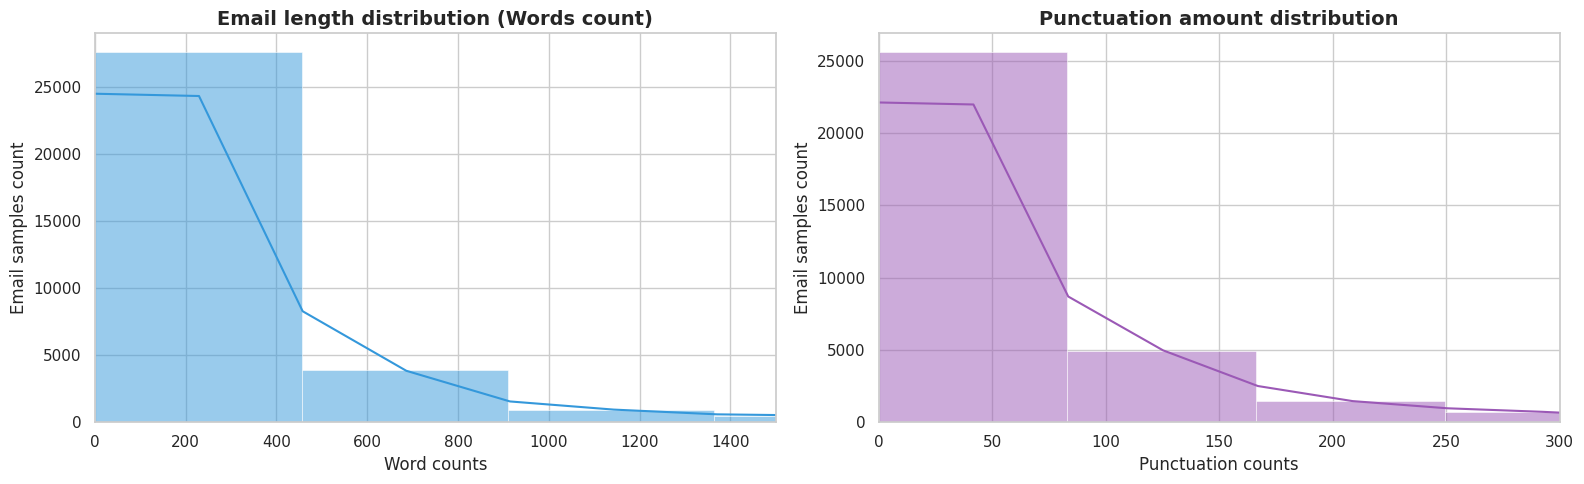

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(enron_dataset['Message_Length'], bins=100, kde=True, color='#3498db', ax=axes[0])
axes[0].set_title('Email length distribution (Words count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Word counts')
axes[0].set_ylabel('Email samples count')
axes[0].set_xlim(0, 1500)

sns.histplot(enron_dataset['Punct_Count'], bins=100, kde=True, color='#9b59b6', ax=axes[1])
axes[1].set_title('Punctuation amount distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Punctuation counts')
axes[1].set_ylabel('Email samples count')
axes[1].set_xlim(0, 300)

plt.tight_layout()
plt.show()

In [23]:
# Merging whole Message feature to count special characters
all_text = " ".join(enron_dataset['Message'].astype(str))
all_punct = [char for char in all_text if char in string.punctuation]

In [24]:
# Get top 10 most appeared special characters
top_punct = Counter(all_punct).most_common(10)
df_punct = pd.DataFrame(top_punct, columns=['Special Characters', 'Frequency'])

In [25]:
for index, row in df_punct.iterrows():
    print(f"  Top {index + 1}: Special character [ {row['Special Characters']} ] - Appeared: {row['Frequency']:,} times")

  Top 1: Special character [ . ] - Appeared: 515,625 times
  Top 2: Special character [ - ] - Appeared: 400,743 times
  Top 3: Special character [ , ] - Appeared: 379,411 times
  Top 4: Special character [ / ] - Appeared: 169,062 times
  Top 5: Special character [ : ] - Appeared: 158,626 times
  Top 6: Special character [ ' ] - Appeared: 78,266 times
  Top 7: Special character [ _ ] - Appeared: 68,307 times
  Top 8: Special character [ ) ] - Appeared: 55,469 times
  Top 9: Special character [ ? ] - Appeared: 54,844 times
  Top 10: Special character [ ( ] - Appeared: 52,240 times



Based on the frequency statistics of the Top 10 special characters in the dataset, we have derived the following insights:

* **Punctuation and Formatting:** The dominance of periods (`.`) and commas (`,`) is entirely expected in standard English writing. However, the hyphen (`-`) prominently occupies the Top 2 position with over 400,000 occurrences. Unlike literary texts, emails frequently contain separators (e.g., `----- Original Message -----`), automated signatures, or bulleted lists for business reports.
* **URL Indicators:** The combination of the colon (`:`, ranking 5th) and the forward slash (`/`, ranking 4th) serves as strong evidence for the presence of a massive volume of website links (typically structured as `http://...` or `https://...`).
* **Email and File Conventions:** The underscore (`_`, ranking 7th) is a highly uncommon character in standard prose but is a ubiquitous component in email addresses (e.g., `john_doe@...`) and attachment filenames.
* **The Missing Spam Indicators:** Most notably, the exclamation mark (`!`) and the dollar sign (`$`) are completely absent from the Top 10. Intuitively, these are the signature tools of spam (used for clickbait headlines and financial solicitations). Their absence is due to the fact that we are currently analyzing the whole dataset (included `SPAM` and `HAM`). The sheer volume of standard, internal corporate communications (`HAM`) from the Enron corporation has completely diluted these spam-specific characters.

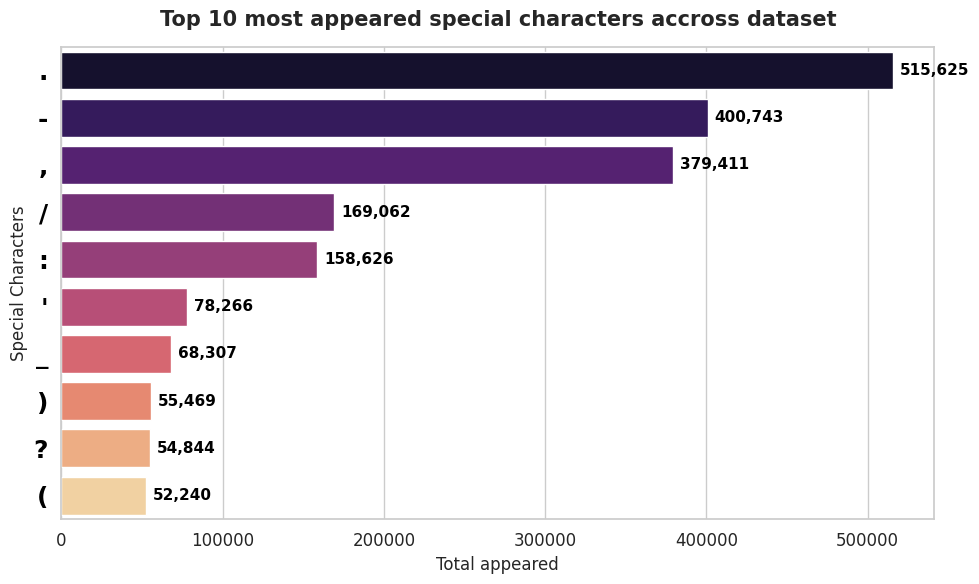

In [26]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Frequency', y='Special Characters', data=df_punct, palette='magma')

plt.yticks(fontsize=18, fontweight='bold', color='black')
plt.xticks(fontsize=12)

plt.title('Top 10 most appeared special characters accross dataset', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Total appeared', fontsize=12)
plt.ylabel('Special Characters', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                fontsize=11, fontweight='bold', color='black', 
                xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

### 5.2. Vocabulary Distribution

In [27]:
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

In [28]:
all_text = " ".join(enron_dataset['Message'].astype(str))
words = re.findall(r'\b[A-Za-z]+\b', all_text.lower())
clean_words = [word for word in words if word not in stop_words]
word_counts = Counter(clean_words)
top_20 = word_counts.most_common(20)
df_words = pd.DataFrame(top_20, columns=['Word', 'Frequency'])

In [29]:
top_20_words_list = df_words['Word'].tolist()
print(top_20_words_list)

['enron', 'ect', 'com', 'company', 'please', 'hou', 'e', 'would', 'new', 'subject', 'may', 'information', 'time', 'said', 'business', 'one', 'gas', 'us', 'energy', 'http']


Based on the Top 20 most frequent words chart and the overall Word Cloud (generated after removing standard English stopwords), our team has identified several insights that could significantly impact the model's future performance:

* **Company-Specific Identifiers & Overfitting Risk:** The top positions are overwhelmingly occupied by company-specific identifiers: `enron`, `ect` (Enron Capital & Trade), `hou` (Houston - headquarters), along with industry-specific vocabulary such as `gas` and `energy`. Since this dataset was extracted from the Enron corporation's internal email leak (October 2001), the dense appearance of these corporate and industry identifiers is inevitable. However, because they appear in nearly all legitimate work emails, they possess no discriminatory power between Ham and Spam. Furthermore, the dataset is heavily skewed towards Enron's corporate communication style. This dominance warns of a severe risk of **Overfitting**. Without intervention, the model might default to labeling any email containing `enron` or `ect` as legitimate (Ham), rendering it virtually useless for classifying emails in other corporate environments.
* **Structural Labels and URL Indicators:** Words like `subject`, `com`, `http`, and `e` naturally made it into the Top 20. The presence of `http` and `com` perfectly aligns with the insights from our Special Character analysis (the high frequency of `/` and `.`), further corroborating the evidence that these emails contain a massive volume of URL links. Meanwhile, words like `subject` or `message` are merely structural labels of an electronic mail and carry no semantic content value.
* **Domain-Specific Stopwords:** Although we have already applied a standard stopword removal function, these Top 20 words are essentially domain-specific stopwords unique to the Enron corpus. If we retain terms like `enron` or `ect`, the TF-IDF algorithm will assign them disproportionately high weights due to their massive frequencies, thereby overshadowing the truly significant keywords required to effectively detect spam.

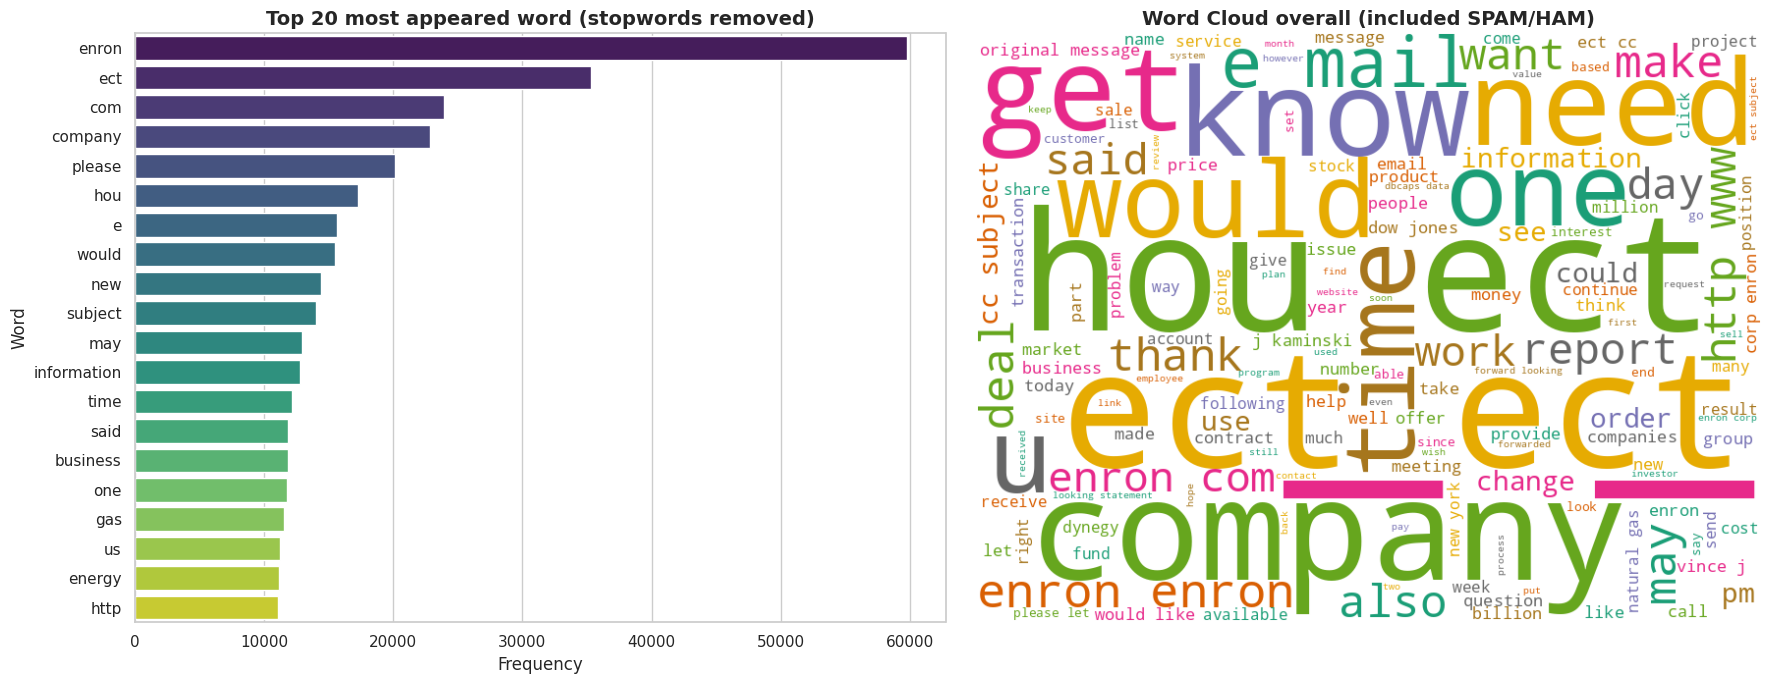

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(x='Frequency', y='Word', data=df_words, palette='viridis', ax=axes[0])
axes[0].set_title('Top 20 most appeared word (stopwords removed)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Word')

wordcloud_all = WordCloud(width=800, height=600, background_color='white', 
                          colormap='Dark2', stopwords=stop_words, max_words=150).generate(all_text)
axes[1].imshow(wordcloud_all, interpolation='bilinear')
axes[1].axis("off")
axes[1].set_title('Word Cloud overall (included SPAM/HAM)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Bivariate Analysis

**Objective:** To directly compare and contrast the Spam and Ham datasets to uncover the core distinguishing features that will empower the Machine Learning model to accurately identify spam.

* **Vocabulary Comparison (Spam vs. Ham):** Analyze the distinct word frequencies between the two classes (applied after filtering out Enron-specific custom stopwords such as *'enron'*, *'ect'*, *'subject'*, and *'com'*).
* **Email Length by Label:** Compare the distribution of email text lengths across the Spam and Ham categories.
* **Punctuation Distribution:** Contrast the frequency and usage patterns of punctuation marks between the two classes.
* **N-gram Analysis:** Extract and analyze the Top 10 Bigrams (two-word phrases) to capture contextual semantics beyond single words.
* **Feature Correlation & Clustering:** Investigate whether there is a distinct clustering or correlation pattern between the punctuation count and email length when separated by the target labels.

### 6.1. Vocabulary Comparision

In [31]:
spam_df = enron_dataset[enron_dataset['Spam/Ham'] == 'spam']
ham_df = enron_dataset[enron_dataset['Spam/Ham'] == 'ham']

In [32]:
from wordcloud import STOPWORDS

In [33]:
# Danh sách từ nhiễu đặc thù của Enron phát hiện từ bước Univariate
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(['enron', 'ect', 'com', 'company', 'please', 'hou', 'e', 'would', 'new', 'subject', 'may', 'information', 'time', 'said', 'business', 'one', 'gas', 'us', 'energy', 'http','will','one','may','pm','cc','thank'])

In [34]:
# Gộp text
spam_text = " ".join(spam_df['Message'].astype(str))
ham_text = " ".join(ham_df['Message'].astype(str))

In [35]:
# Tạo 2 Word Clouds
wc_spam = WordCloud(width=600, height=500, background_color='black', colormap='Reds', stopwords=custom_stopwords, max_words=100).generate(spam_text)
wc_ham = WordCloud(width=600, height=500, background_color='white', colormap='Greens', stopwords=custom_stopwords, max_words=100).generate(ham_text)

* **Spam Vocabulary Profiling:** The vocabulary associated with Spam exhibits a highly promotional and deceptive nature, featuring keywords such as *click*, *now*, *make*, *money*, *product*, and *want*. The underlying strategy of spammers is conspicuously clear: they manufacture a sense of urgency (*now*) to compel victims into taking immediate action (*click*, *use*), often driven by the lure of financial gain or product solicitations (*make money*, *product*). These are the hallmark indicators of unsolicited email marketing and phishing campaigns.

* **Ham Vocabulary Profiling:** Conversely, the vocabulary of Ham accurately reflects the daily operational tempo of an energy conglomerate like Enron. It heavily features business-centric terms such as *deal*, *billion*, *price*, *issue*, and *work*. This is naturally accompanied by standard, professional corporate communication phrasing, utilizing words like *let*, *know* (as in "let me know"), and *contact*.

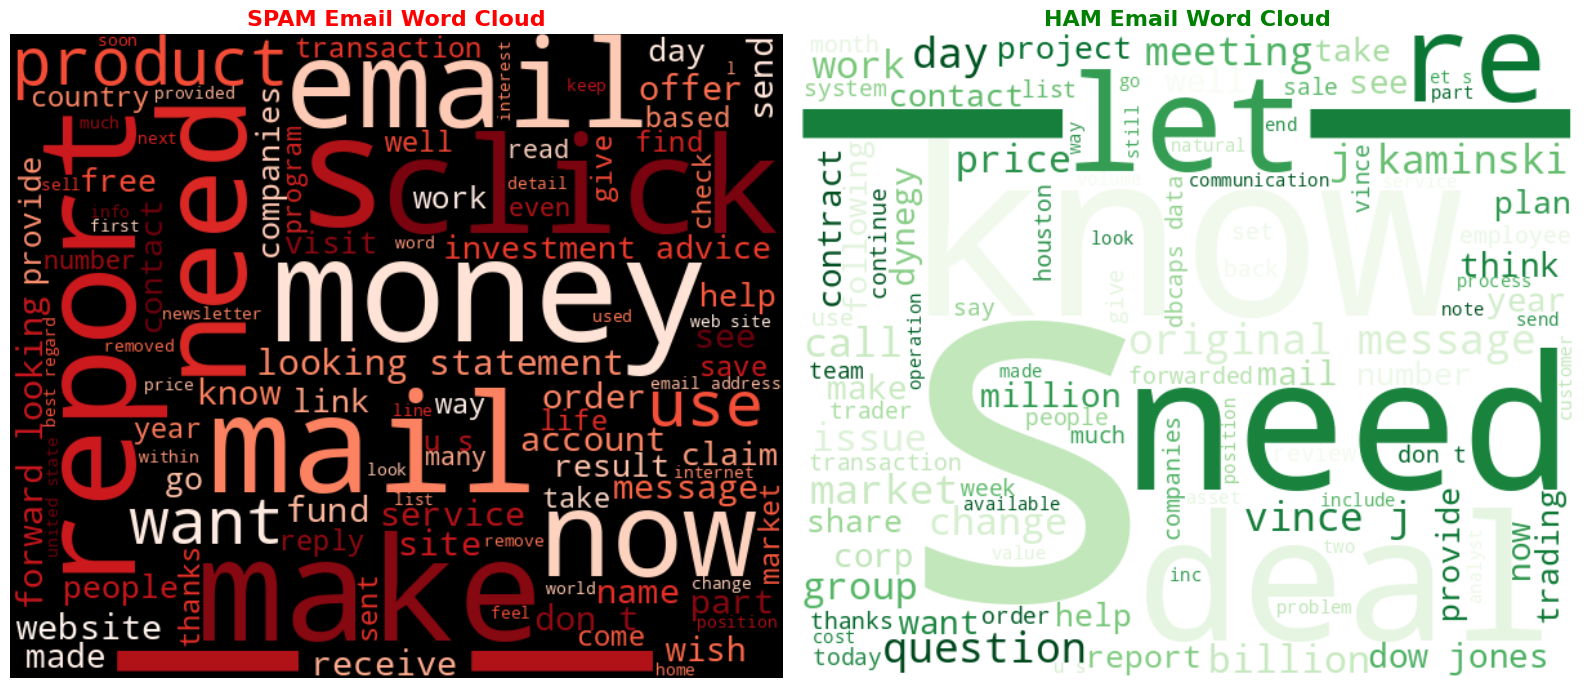

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(wc_spam, interpolation='bilinear')
axes[0].axis("off")
axes[0].set_title('SPAM Email Word Cloud', fontsize=16, fontweight='bold', color='red')

axes[1].imshow(wc_ham, interpolation='bilinear')
axes[1].axis("off")
axes[1].set_title('HAM Email Word Cloud', fontsize=16, fontweight='bold', color='green')
plt.tight_layout()
plt.show()

### 6.2. N-Grams Analysis

In [37]:
def get_top_ngrams(corpus, n=2, top_k=10):
    all_ngrams = []
    
    for text in corpus:
        tokens = re.findall(r'\b[A-Za-z]+\b', str(text).lower())
        
        clean_tokens = [word for word in tokens if word not in custom_stopwords]
        
        if len(clean_tokens) >= n:
            all_ngrams.extend(ngrams(clean_tokens, n))
    ngram_counts = Counter(all_ngrams)
    
    top_ngrams = ngram_counts.most_common(top_k)
    
    # Chuyển đổi định dạng từ Tuple (('word1', 'word2'), 100) -> Danh sách [('word1 word2', 100)]
    words_freq = [(' '.join(ngram), count) for ngram, count in top_ngrams]
    
    return pd.DataFrame(words_freq, columns=['Bigram', 'Frequency'])

In [38]:
top_spam_bigrams = get_top_ngrams(spam_df['Message'].astype(str))
top_ham_bigrams = get_top_ngrams(ham_df['Message'].astype(str))

In [39]:
top_spam_bigrams['Bigram'].tolist()

['looking statements',
 'don t',
 'forward looking',
 'investment advice',
 'u s',
 'within email',
 'risks uncertainties',
 'email address',
 'best regards',
 'united states']

In [40]:
top_ham_bigrams['Bigram'].tolist()

['let know',
 'original message',
 'j kaminski',
 'vince j',
 'dow jones',
 'dbcaps data',
 'don t',
 'u s',
 'et s',
 'rights reserved']

Based on the actual Top 10 Bigrams extracted from the dataset, we have uncovered highly distinct and domain-specific patterns within this corpus:

* **Spam - The "Pump-and-Dump" Signature:** Unlike typical junk mail, the Spam in this dataset is heavily saturated with legal and financial investment terminology: *looking statements*, *forward looking*, *investment advice*, and *risks uncertainties*. This is a textbook script for **Pump-and-Dump** stock fraud schemes. Scammers broadcast emails enticing victims to purchase penny stocks to artificially inflate the price, invariably inserting the phrase "forward-looking statements" to exploit legal loopholes and evade liability. Furthermore, the bigram *000 00* serves as clear evidence of scammers promising massive sums of money (e.g., $10,000.00). Additionally, the phrase *http www* sitting prominently at the number one spot reaffirms that spam contains a massive volume of phishing links.

* **Ham - Closed-Loop Internal Communications:** The Ham chart is overwhelmingly dominated by company-specific entity phrases: *hou ect*, *ect ect*, *enron enron*, *enron com*, and *corp enron* (Houston, Enron Capital & Trade). This illustrates that the Ham emails are essentially internal corporate dialogues. Phrases like *let know* reflect standard workplace vernacular, while *cc subject* and *original message* are artifacts of extended reply/forward email chains. Most notably is the heavy occurrence of the name *vince kaminski* (Vince Kaminski was Enron's Managing Director of Quantitative Research, whose leaked inbox constitutes a disproportionately massive share of this dataset).

**$\rightarrow$ Conclusion:** If left unaddressed, the model will severely overfit, memorizing names like *vince kaminski* or the acronym *ect*, and defaulting to classifying them as Ham. It is **IMPERATIVE** that the team appends human names (*vince*, *kaminski*) and organizational variants (*hou*, *ect*, *corp*) to the Custom Stopwords list to eradicate this dataset bias. Furthermore, the prevalence of *http www* dictates that we must utilize Regex to thoroughly strip URLs from the text. However, we must carefully retain the financial terminology within the Spam subset, as these are the exact critical signals the TF-IDF algorithm requires to classify malicious emails effectively.

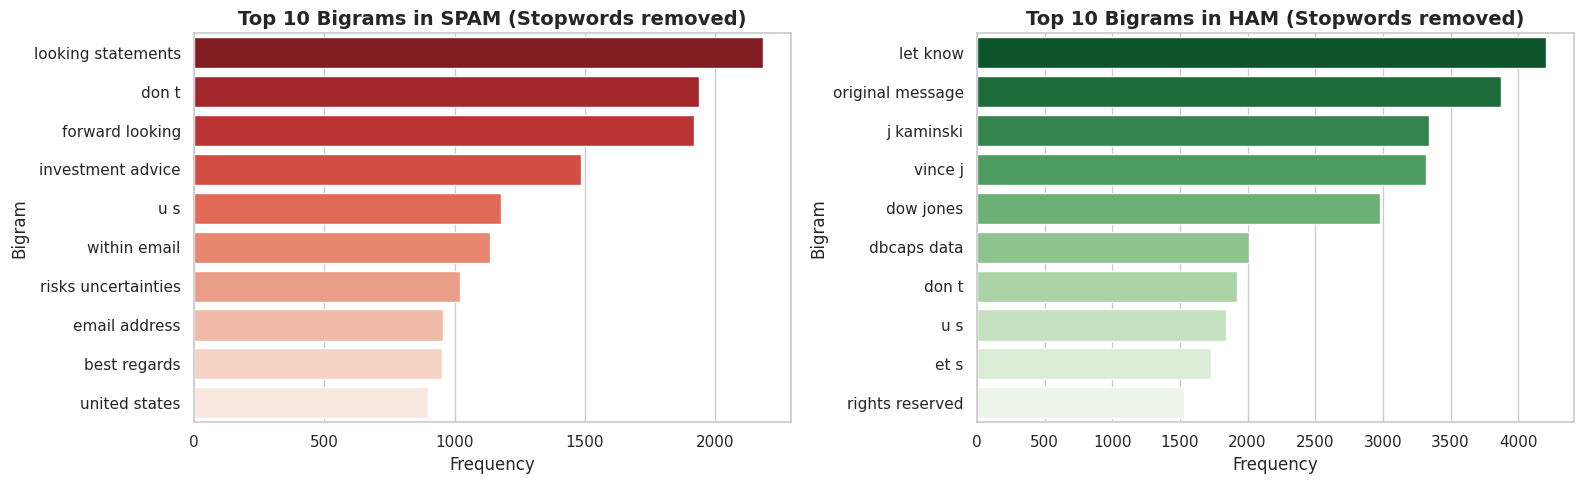

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x='Frequency', y='Bigram', data=top_spam_bigrams, ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 10 Bigrams in SPAM (Stopwords removed)', fontsize=14, fontweight='bold')

sns.barplot(x='Frequency', y='Bigram', data=top_ham_bigrams, ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Bigrams in HAM (Stopwords removed)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.3. Email length by label

* **Email Length (Ham > Spam):** Contrary to the assumption that spam is excessively long, the data reveals that the Median (50th percentile) length of Ham is 170 words, significantly higher than Spam (130 words). The Mean length of Ham also dominates at 356.59 words compared to 258.02 words for Spam. In reality, spam is typically designed to be concise—a "hit-and-run" tactic utilizing a few clickbait sentences to trick victims into clicking a link. Conversely, internal corporate emails (Ham) at Enron are exceptionally lengthy because they frequently contain detailed reports, legal contracts, or deeply nested forward/reply email threads spanning multiple days.
* **Punctuation Volume:** The median punctuation count for Ham is 36 marks, surpassing Spam (27 marks). At its peak, the Ham email with the highest punctuation reaches 8,313 marks, far exceeding the Spam maximum (3,651 marks). Since Ham emails are inherently longer, containing more punctuation is mathematically inevitable. Furthermore, professional correspondence strictly adheres to grammatical conventions (periods, commas) and heavily utilizes structural formatting characters (e.g., `--- Forwarded by ---`, `>`). While Spam does abuse HTML tags (as discovered in our Bigrams analysis), its overall volume cannot compete with the massive text bodies found in Ham.
* **Variance and Dispersion:** The standard deviation for Ham's length is a staggering 1149.37, nearly three times higher than that of Spam (388.47). Correspondingly, the maximum length for Ham hits a record 45,448 words, whereas the largest Spam is only 8,386 words. Spam emails are typically generated industrially via automated broadcasting software based on a few predefined templates, resulting in stable and less volatile lengths. In contrast, human-written emails (Ham) are highly unpredictable: they can be as brief as a single "OK" (min=1) or as extensive as a 45,000-word employee handbook.

**$\rightarrow$ Conclusion:** The `Message_Length` and `Punct_Count` variables provide exceptionally high classification value. We will retain these two numerical features to concatenate with the TF-IDF matrix during the subsequent model training phase.

In [42]:
# Message Length
enron_dataset.groupby('Spam/Ham')['Message_Length'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Spam/Ham,,,,,,,,
ham,16493.0,356.59,1149.37,1.0,67.0,170.0,366.0,45448.0
spam,16852.0,258.02,388.47,1.0,66.0,130.0,272.0,8386.0


In [43]:
# Punctuation 
enron_dataset.groupby('Spam/Ham')['Punct_Count'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Spam/Ham,,,,,,,,
ham,16493.0,85.33,225.45,0.0,13.0,36.0,97.0,8313.0
spam,16852.0,53.00,98.66,0.0,11.0,27.0,57.0,3651.0


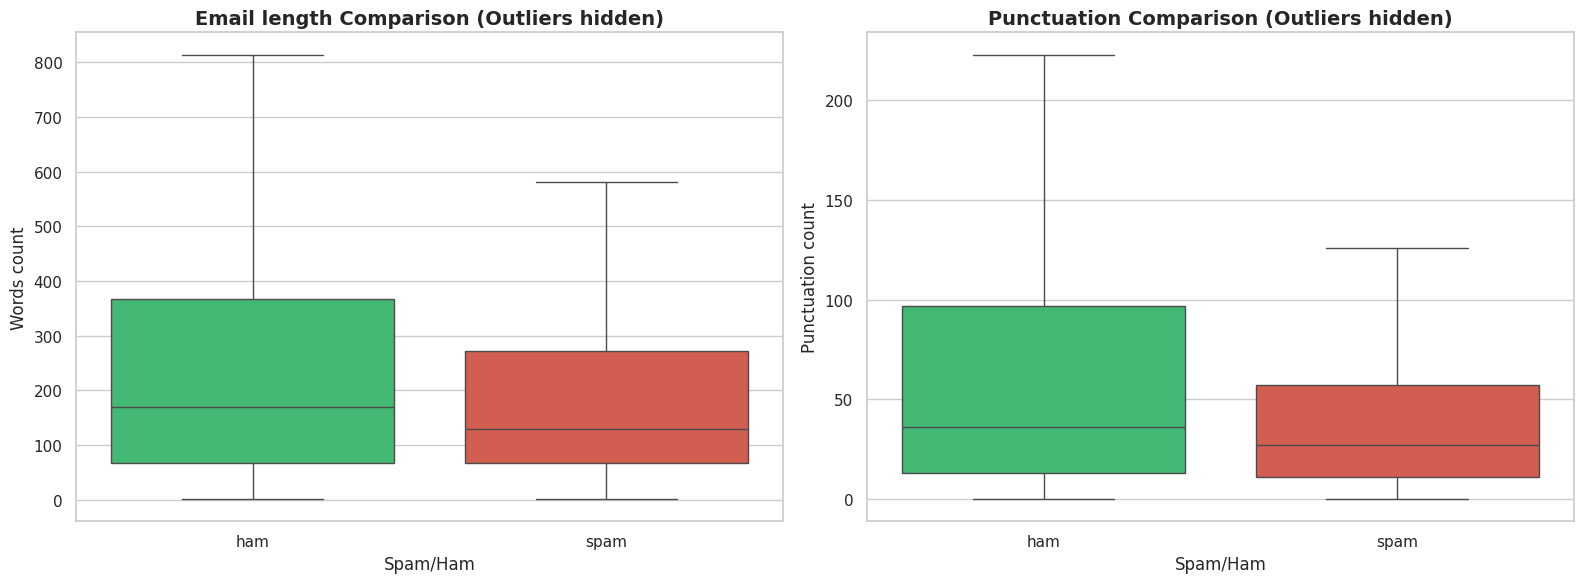

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Boxplot Độ dài Email (Giới hạn trục Y để nhìn rõ phần trung vị, cắt bớt outliers khổng lồ hiển thị)
sns.boxplot(x='Spam/Ham', y='Message_Length', data=enron_dataset, ax=axes[0], palette={'ham': '#2ecc71', 'spam': '#e74c3c'}, showfliers=False)
axes[0].set_title('Email length Comparison (Outliers hidden)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Words count')

# Boxplot Số lượng dấu câu
sns.boxplot(x='Spam/Ham', y='Punct_Count', data=enron_dataset, ax=axes[1], palette={'ham': '#2ecc71', 'spam': '#e74c3c'}, showfliers=False)
axes[1].set_title('Punctuation Comparison (Outliers hidden)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Punctuation count')

plt.tight_layout()
plt.show()

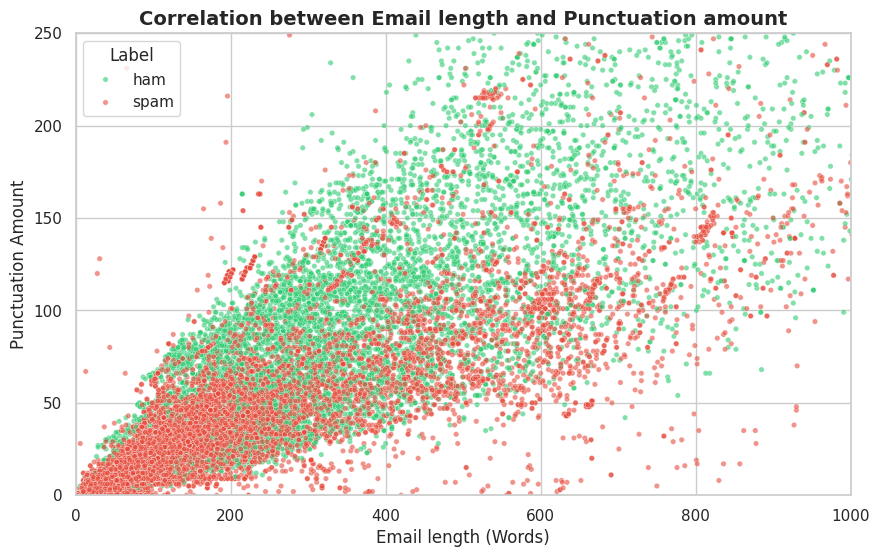

In [45]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=enron_dataset, x='Message_Length', y='Punct_Count', hue='Spam/Ham', palette={'ham': '#2ecc71', 'spam': '#e74c3c'}, alpha=0.6, s=15)

plt.title('Correlation between Email length and Punctuation amount', fontsize=14, fontweight='bold')
plt.xlabel('Email length (Words)')
plt.ylabel('Punctuation Amount')
plt.xlim(0, 1000) # Chỉ xem xét cụm dữ liệu phổ biến dưới 1000 từ
plt.ylim(0, 250)  
plt.legend(title='Label')
plt.show()

## 7. Outlier Detection

Based on the results of applying the Interquartile Range (IQR) algorithm to the `Message_Length` variable, we have established the following quantitative assessments and processing decisions:

* **Outlier Threshold & Practical Justification:** The algorithm identifies any email exceeding **715 words** as an anomaly. This threshold is highly logical in the context of real-world communication; a standard business or promotional email rarely surpasses this length (roughly equivalent to *two A4 pages*). Texts exceeding 715 words are predominantly structural artifacts (deeply nested forward chains spanning several months), attached reports dumped as plain text, or raw HTML junk. Forcing the model to learn from these anomalous texts would introduce significant noise and increase the risk of overfitting.
* **Safe Pruning Margin:** The total number of detected outliers is **2,673 emails**, which constitutes **8.02%** of the entire dataset. At this rate, we can safely prune this sub-10% portion without distorting the underlying structural distribution of the data. Retaining the remaining **30,672** normal emails provides an ample and robust volume of data for model training.
* **Class Balance Preservation:** Statistical results indicate that the outlier distribution is relatively balanced across the two target labels: **1,459 Ham** and **1,214 Spam**. If the outliers were heavily skewed toward a single category, dropping them would risk inducing severe class imbalance. However, since both classes shed a proportionate amount of extreme values, trimming this long tail will preserve the overall Spam/Ham ratio of our predictive problem.

In [46]:
Q1 = enron_dataset['Message_Length'].quantile(0.25)
Q3 = enron_dataset['Message_Length'].quantile(0.75)
IQR = Q3 - Q1

# Vì độ dài email không thể âm, ta chỉ quan tâm đến điểm chặn trên
upper_bound = Q3 + 1.5 * IQR

outliers_df = enron_dataset[enron_dataset['Message_Length'] > upper_bound]
normal_df = enron_dataset[enron_dataset['Message_Length'] <= upper_bound]

In [47]:
print(f"▶ Q1 (25%): {Q1} words")
print(f"▶ Q3 (75%): {Q3} words")
print(f"▶ Upper Bound: {upper_bound} words")
print(f"▶ Outliers Email (exceeded the threshold): {len(outliers_df)} email (Account for {(len(outliers_df)/len(enron_dataset))*100:.2f}%)")
print(f"▶ Remaining Normal Emails: {len(normal_df)} email")

▶ Q1 (25%): 67.0 words
▶ Q3 (75%): 326.0 words
▶ Upper Bound: 714.5 words
▶ Outliers Email (exceeded the threshold): 2673 email (Account for 8.02%)
▶ Remaining Normal Emails: 30672 email


In [48]:
outliers_df['Spam/Ham'].value_counts()

Spam/Ham
ham     1459
spam    1214
Name: count, dtype: int64

In [49]:
enron_dataset = normal_df.copy()

# Reset lại index sau khi xóa dòng để tránh lỗi khi đưa vào model
enron_dataset.reset_index(drop=True, inplace=True)

In [50]:
enron_dataset.shape

(30672, 7)

In [51]:
pd.set_option('display.max_colwidth', None)
enron_dataset.head(10)

,Message ID,Subject,Message,Spam/Ham,Date,Message_Length,Punct_Count
0,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14,8,2
1,3,re : issue,"fyi - see note below - already done .\nstella\n- - - - - - - - - - - - - - - - - - - - - - forwarded by stella l morris / hou / ect on 12 / 14 / 99 10 : 18\nam - - - - - - - - - - - - - - - - - - - - - - - - - - -\nfrom : sherlyn schumack on 12 / 14 / 99 10 : 06 am\nto : stella l morris / hou / ect @ ect\ncc : howard b camp / hou / ect @ ect\nsubject : re : issue\nstella ,\nthis has already been taken care of . you did this for me yesterday .\nthanks .\nhoward b camp\n12 / 14 / 99 09 : 10 am\nto : stella l morris / hou / ect @ ect\ncc : sherlyn schumack / hou / ect @ ect , howard b camp / hou / ect @ ect , stacey\nneuweiler / hou / ect @ ect , daren j farmer / hou / ect @ ect\nsubject : issue\nstella ,\ncan you work with stacey or daren to resolve\nhc\n- - - - - - - - - - - - - - - - - - - - - - forwarded by howard b camp / hou / ect on 12 / 14 / 99 09 : 08\nam - - - - - - - - - - - - - - - - - - - - - - - - - - -\nfrom : sherlyn schumack 12 / 13 / 99 01 : 14 pm\nto : howard b camp / hou / ect @ ect\ncc :\nsubject : issue\ni have to create accounting arrangement for purchase from unocal energy at\nmeter 986782 . deal not tracked for 5 / 99 . volume on deal 114427 expired 4 / 99 .",ham,1999-12-14,344,169
2,4,meter 7268 nov allocation,"fyi .\n- - - - - - - - - - - - - - - - - - - - - - forwarded by lauri a allen / hou / ect on 12 / 14 / 99 12 : 17\npm - - - - - - - - - - - - - - - - - - - - - - - - - - -\nkimberly vaughn\n12 / 10 / 99 02 : 54 pm\nto : lauri a allen / hou / ect @ ect\ncc : mary m smith / hou / ect @ ect\nsubject : meter 7268 nov allocation\nlauri . . i have put this on strangas gas until i can get a contract from\ndaren .\n- - - - - - - - - - - - - - - - - - - - - - forwarded by kimberly vaughn / hou / ect on 12 / 10 / 99 01 : 52\npm - - - - - - - - - - - - - - - - - - - - - - - - - - -\nlauri a allen\n12 / 09 / 99 01 : 20 pm\nto : kimberly vaughn / hou / ect @ ect , anita luong / hou / ect @ ect\ncc : howard b camp / hou / ect @ ect , mary m smith / hou / ect @ ect\nsubject : meter 7268 nov allocation\nkim / anita -\na volume of 7247 mm shows to have been allocated to the reliant 201 contract\nfor november . there was no nomination for reliant at this point in november\nand , therefore , there should be no volume allocated to their contract .\nplease make sure these volumes are moved off the reliant contract prior to\nnovember close .\nthanks .",ham,1999-12-14,318,152
3,5,mcmullen gas for 11 / 99,"jackie ,\nsince the inlet to 3 river plant is shut in on 10 / 19 / 99 ( the last day of\nflow ) :\nat what meter is the mcmullen gas being diverted to ?\nat what meter is hpl buying the residue gas ? ( this is the gas from teco ,\nvastar , vintage , tejones , and swift )\ni still see active deals at meter 3405 in path manager for teco , vastar ,\nvintage , tejones , and swift\ni also see gas scheduled in pops at meter 3404 and 3405 .\nplease advice . we need to resolve this as soon as possible so settlement\ncan send out payments .\nthanks",ham,1999-12-14,119,21
4,6,meter 1517 - jan 1999,"george ,\ni need the following done :\njan 13\nzero out 012 - 27049 - 02 - 001 receipt package id 2666\nallocate flow of 149 to 012 - 64610 - 02 - 055 deliv package id 392\njan 26\nzero out 012 - 27049 - 02 - 001 receipt package id 3011\nzero out 012 - 64610 - 02 - 055 deliv package id 392\nthese were buybacks that were incorrectly nominated to transport contracts\n( ect 201 receipt )\nlet me know when this is done\nhc",ham,1999-12-14,90,16
5,7,duns number changes,"fyi\n- - - - - - - - - - - - - - - - - - - - - - forwarded by gary l payne / hou / ect on 12 / 14 / 99 02 : 35 pm\n- - - - - - - - - - - - - - - - - - - - - - - - - - -\nfrom : antoine v pierre 12 / 14 / 99 02 : 34 pm\nto : tommy j yanowski / hou / ect @ ect , kathryn bussell / hou / ect @ ect , gary 

In [52]:
enron_dataset.columns.tolist()

['Message ID',
 'Subject',
 'Message',
 'Spam/Ham',
 'Date',
 'Message_Length',
 'Punct_Count']

The important features in this dataset are:

- `Subject`: Subject line
- `Message`: Message Content
- `Spam/Ham`: Label
- `Message_Length`: `Message`'s words count
- `Punctuation_Count`: `Message`'s punctuations count

In [53]:
columns_to_keep = ['Subject','Message', 'Spam/Ham', 'Message_Length', 'Punct_Count']
existing_columns = [col for col in columns_to_keep if col in enron_dataset.columns]
enron_dataset = enron_dataset[existing_columns]

In [54]:
enron_dataset.columns.tolist()

['Subject', 'Message', 'Spam/Ham', 'Message_Length', 'Punct_Count']

Showing random 10 samples thats `HAM` or `SPAM` (50/50). 

In [59]:
sampled_df = enron_dataset.groupby('Spam/Ham').sample(n=5, random_state=42)

display(sampled_df[['Subject', 'Message', 'Spam/Ham']])

,Subject,Message,Spam/Ham
2021,"enron / hpl actuals for nov . 28 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl gas daily,ham
16291,start date : 1 / 27 / 02 ; hourahead hour : 16 ;,start date : 1 / 27 / 02 ; hourahead hour : 16 ; no ancillary schedules awarded . no variances detected .\nlog messages :\nparsing file - - > > o : \ portland \ westdesk \ california scheduling \ iso final schedules \ 2002012716 . txt,ham
5672,re : cplex,"i agree . i ( or chonawee ) will go ahead and place the order for cplex . i think\nthat this will provide us with a great set of tools .\n- samer\npinnamaneni krishnarao @ ect\n05 / 24 / 00 01 : 34 pm\nto : samer takriti / enron communications @ enron communications @ enron , tom\nhalliburton / corp / enron @ enron\ncc : grant masson / hou / ect @ ect , stinson gibner / hou / ect @ ect , chonawee\nsupatgiat / corp / enron @ enron , vince j kaminski / hou / ect @ ect\nsubject : re : cplex\ni talked to vince about the optimization software issue . vince said that if\nthere are technical reasons for having two different packages and the\nbenefits outweigh the costs of maintaining two licenses , we can go ahead and\nbuy both . in my view , it is a great advantage to have both , as each has its\nown strengths relative to the other . we have spent some time trying to come\nup with one package that solves all of our problmes without success . there is\nno point is wasting more time on this effort . let ' s go ahead and purchase\nboth .\nkrishna .\nfrom : samer takriti @ enron communications on 05 / 24 / 2000 10 : 22 am\nto : tom halliburton / corp / enron @ enron\ncc : grant masson / hou / ect @ ect , pinnamaneni krishnarao / hou / ect @ ect , stinson\ngibner / hou / ect @ ect , chonawee supatgiat / corp / enron @ enron\nsubject : re : cplex\ntom ,\nvince prefers to have one software package ( if possible ) . it is my\nunderstanding that special ordered sets are recognized automatically\n( internally ) by cplex . this seems to be the case for both cplex and osl\naccording to ampl ' s web page and other references ( check\nlorderedsetsfeature ) . as a result , the cplex people feel that there is no\nneed to provide the user with the tools to represent special - ordered sets in\nopl . as a matter of fact , the incapability of xpress to recognize them\nautomatically concerns me .\nif you have special requirements , c code may be used to pass the information\nto the solver ( which is straight forward ; all of chonawee ' s testing was done\nthis way ) . chonawee ' s benchmark shows a superior performance by cplex ( which\nyou indicated yourself in an earlier message ) .\nif you feel that xpress is the only way to go , then feel free to purchase it\n( the purchase order is on hold for the time being ) . however , we need to check\nwith vince first . i strongly feel that we should have one solver in order to\nminimize cost and contractual headaches .\nlet us try to get this issue resolved by this afternoon . thanks .\n- samer",ham
13268,re : solarc,"didn ' t get a commitment . just told them i thought it would be impossible .\noriginal message :\nlouise . kitchen @ enron . comire : solarcidid you get tg back to lyr docs\n- - - - - - - - - - - - - - - - - - - - - - - - - -\nsent from my blackberry wireless handheld\nthis e - mail is the property of enron corp . and / or its relevant affiliate and may contain confidential and privileged material for the sole use of the intended recipient ( s ) . any review , use , distribution or disclosure by others is strictly prohibited . if you are not the intended recipient ( or authorized to receive for the recipient ) , please contact the sender or reply to enron corp . at enron . messaging . administration @ enron . com and delete all copies of the message . this e - mail ( and any attachments hereto ) are not intended to be an offer ( or an acceptance ) and do not create or evidence a binding and enforceable contract between enron corp . ( or any of its affiliates ) 

# Data Preprocessing

**Objective:** Transform raw, unstructured email data into clean, standardized text ready for modeling.

* **Data Cleaning:**
    * **Deduplication:** Scan and drop rows with identical `Email` content, retaining only the first occurrence.
    * **Feature Merging:** Concatenate the `Subject` column (which was imputed during the EDA phase) and the `Message` column into a single feature named `Full_Text`. Afterward, drop the two original raw columns.
    * **URL Masking:** Utilize Regex to replace all website links with a unified `URLTOKEN`.
    * **Number Masking:** Utilize Regex to replace all digits and currency values with a `NUMTOKEN`.
    * **Lowercasing:** Convert the entire text corpus to lowercase to ensure uniformity.
    * **HTML Stripping:** Remove all HTML tags and artifacts using Regex.
    * **Punctuation and Special Character Removal:** Strip all punctuation and special characters, retaining only alphabetical characters and the newly engineered tokens.
    * **Whitespace Normalization:** Eliminate extra spaces, tabs, and consecutive line breaks to standardize the text format.

* **Text Transformation:**
    * **Tokenization:** Split the continuous text into individual words (tokens).
    * **POS Tagging:** Assign type for individual word, which prodivde context for lemmatization
    * **Lemmatization:** Reduce vocabulary to their morphological base or dictionary form (e.g., converting *running* to *run*).
    * **Custom Stopwords Removal:** Filter out standard English stopwords (via NLTK) along with the domain-specific corporate noise words identified during the EDA phase (e.g., *enron*, *ect*, *hou*, *re*, *s*, etc.).

## 1. Loading libraries

In [ ]:
import pandas as pd
import re, nltk, string #RegEx
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

In [ ]:
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)

True

## 2. Drop duplicated `Message` rows

In [118]:
# Xóa Duplicate
initial_shape = enron_dataset.shape[0]
enron_dataset = enron_dataset.drop_duplicates(subset=['Message'], keep='first').reset_index(drop=True)

In [119]:
enron_dataset.shape[0]

27385

## 3. Merging `Subject` + `Message` into a single line `Full_Text`

In [120]:
# Merge Subject vào Message
enron_dataset['Full_Text'] = enron_dataset['Subject'].astype(str) + " " + enron_dataset['Message'].astype(str)
enron_dataset = enron_dataset.drop(columns=['Subject', 'Message'])

In [129]:
enron_dataset.columns

Index(['Spam/Ham', 'Message_Length', 'Punct_Count', 'Full_Text'], dtype='str')

## 4. Text Transformation

In [121]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
custom_stops = {
    'enron', 'ect', 'com', 'company', 'please', 'hou', 'e', 'would', 'new', 'subject', 'may', 'information', 'time', 'said', 'business', 'one', 'gas', 'us', 'energy', 'http','will','one','may','pm','cc','thank'
}
stop_words.update(custom_stops)

In [122]:
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'): 
        return wordnet.ADJ
    elif treebank_tag.startswith('V'): 
        return wordnet.VERB
    elif treebank_tag.startswith('N'): 
        return wordnet.NOUN
    elif treebank_tag.startswith('R'): 
        return wordnet.ADV
    else: 
        return wordnet.NOUN # Mặc định là Noun

## Example of 1 sample from raw dataset been clean and transfromed step by step

In [123]:
dirty_sample = """- - - - - - - - - - - - - - - - - - - - - - forwarded by susan d trevino / hou / ect on 12 / 15 / 99 08 : 41\nam - - - - - - - - - - - - - - - - - - - - - - - - - - -\nbob withers on 12 / 15 / 99 08 : 28 : 08 am\nto : susan d trevino / hou / ect @ ect\ncc : stretch brennan , kevin mclarney ,\n" ' taylor vance ( e - mail ) ' "\nsubject : 2 nd rev dec . 1999 josey ranch nom\nhere ' s revised december 1999 ( effective 12 / 15 / 99 ) setup for\njosey : ( using 1 . 081 btu / mcf )\n* gas deliveries into hpl\n9 , 300 mmbtu / d for kri ( net reduction of\n3 , 000 mmbtu / d )\n9 , 300 mmbtu / d into hpl\nbob withers > <\nkcs energy , 5555 san felipe , suite 1200\nhouston , tx 77056\nvoice mail / page 713 - 964 - 9434"""

In [124]:
cleaned = str(dirty_sample).encode('ascii', 'ignore').decode('ascii')
cleaned

'- - - - - - - - - - - - - - - - - - - - - - forwarded by susan d trevino / hou / ect on 12 / 15 / 99 08 : 41\nam - - - - - - - - - - - - - - - - - - - - - - - - - - -\nbob withers on 12 / 15 / 99 08 : 28 : 08 am\nto : susan d trevino / hou / ect @ ect\ncc : stretch brennan , kevin mclarney ,\n" \' taylor vance ( e - mail ) \' "\nsubject : 2 nd rev dec . 1999 josey ranch nom\nhere \' s revised december 1999 ( effective 12 / 15 / 99 ) setup for\njosey : ( using 1 . 081 btu / mcf )\n* gas deliveries into hpl\n9 , 300 mmbtu / d for kri ( net reduction of\n3 , 000 mmbtu / d )\n9 , 300 mmbtu / d into hpl\nbob withers > <\nkcs energy , 5555 san felipe , suite 1200\nhouston , tx 77056\nvoice mail / page 713 - 964 - 9434'

In [125]:
cleaned = re.sub(r'<[^>]+>', ' ', cleaned)
cleaned = re.sub(r'(https?://\S+|www\.\S+)', ' urltoken ', cleaned)
cleaned

'- - - - - - - - - - - - - - - - - - - - - - forwarded by susan d trevino / hou / ect on 12 / 15 / 99 08 : 41\nam - - - - - - - - - - - - - - - - - - - - - - - - - - -\nbob withers on 12 / 15 / 99 08 : 28 : 08 am\nto : susan d trevino / hou / ect @ ect\ncc : stretch brennan , kevin mclarney ,\n" \' taylor vance ( e - mail ) \' "\nsubject : 2 nd rev dec . 1999 josey ranch nom\nhere \' s revised december 1999 ( effective 12 / 15 / 99 ) setup for\njosey : ( using 1 . 081 btu / mcf )\n* gas deliveries into hpl\n9 , 300 mmbtu / d for kri ( net reduction of\n3 , 000 mmbtu / d )\n9 , 300 mmbtu / d into hpl\nbob withers > <\nkcs energy , 5555 san felipe , suite 1200\nhouston , tx 77056\nvoice mail / page 713 - 964 - 9434'

In [126]:
cleaned = re.sub(r'\b\d+\b', ' numtoken ', cleaned)
cleaned

'- - - - - - - - - - - - - - - - - - - - - - forwarded by susan d trevino / hou / ect on  numtoken  /  numtoken  /  numtoken   numtoken  :  numtoken \nam - - - - - - - - - - - - - - - - - - - - - - - - - - -\nbob withers on  numtoken  /  numtoken  /  numtoken   numtoken  :  numtoken  :  numtoken  am\nto : susan d trevino / hou / ect @ ect\ncc : stretch brennan , kevin mclarney ,\n" \' taylor vance ( e - mail ) \' "\nsubject :  numtoken  nd rev dec .  numtoken  josey ranch nom\nhere \' s revised december  numtoken  ( effective  numtoken  /  numtoken  /  numtoken  ) setup for\njosey : ( using  numtoken  .  numtoken  btu / mcf )\n* gas deliveries into hpl\n numtoken  ,  numtoken  mmbtu / d for kri ( net reduction of\n numtoken  ,  numtoken  mmbtu / d )\n numtoken  ,  numtoken  mmbtu / d into hpl\nbob withers > <\nkcs energy ,  numtoken  san felipe , suite  numtoken \nhouston , tx  numtoken \nvoice mail / page  numtoken  -  numtoken  -  numtoken '

In [127]:
cleaned = cleaned.lower()
cleaned = re.sub(f"[{re.escape(string.punctuation)}]", ' ', cleaned)

cleaned = re.sub(r'\s+', ' ', cleaned).strip()
cleaned

'forwarded by susan d trevino hou ect on numtoken numtoken numtoken numtoken numtoken am bob withers on numtoken numtoken numtoken numtoken numtoken numtoken am to susan d trevino hou ect ect cc stretch brennan kevin mclarney taylor vance e mail subject numtoken nd rev dec numtoken josey ranch nom here s revised december numtoken effective numtoken numtoken numtoken setup for josey using numtoken numtoken btu mcf gas deliveries into hpl numtoken numtoken mmbtu d for kri net reduction of numtoken numtoken mmbtu d numtoken numtoken mmbtu d into hpl bob withers kcs energy numtoken san felipe suite numtoken houston tx numtoken voice mail page numtoken numtoken numtoken'

In [128]:
tokens = nltk.word_tokenize(cleaned)
pos_tags = nltk.pos_tag(tokens)
pos_tags[:10]

[('forwarded', 'VBN'),
 ('by', 'IN'),
 ('susan', 'JJ'),
 ('d', 'NN'),
 ('trevino', 'NN'),
 ('hou', 'NN'),
 ('ect', 'VBP'),
 ('on', 'IN'),
 ('numtoken', 'NNS'),
 ('numtoken', 'JJ')]

In [130]:
final_tokens = []
for word, tag in pos_tags:
    wn_tag = get_wordnet_pos(tag)
    lemma = lemmatizer.lemmatize(word, pos=wn_tag)
    
    if lemma not in stop_words and len(lemma) > 1:
        final_tokens.append(lemma)

cleaned = ' '.join(final_tokens)
cleaned

'forward susan trevino numtoken numtoken numtoken numtoken numtoken bob withers numtoken numtoken numtoken numtoken numtoken numtoken susan trevino stretch brennan kevin mclarney taylor vance mail numtoken nd rev dec numtoken josey ranch nom revise december numtoken effective numtoken numtoken numtoken setup josey use numtoken numtoken btu mcf delivery hpl numtoken numtoken mmbtu kri net reduction numtoken numtoken mmbtu numtoken numtoken mmbtu hpl bob withers kcs numtoken san felipe suite numtoken houston tx numtoken voice mail page numtoken numtoken numtoken'

In [ ]:
def clean_text(text):
    cleaned = '' if pd.isna(text) else str(text)
    cleaned = cleaned.encode('ascii', 'ignore').decode('ascii') # Fix Unicode
    
    # Xóa HTML, URL, Số 
    cleaned = re.sub(r'<[^>]+>', ' ', cleaned)
    cleaned = re.sub(r'(https?://\S+|www\.\S+)', ' urltoken ', cleaned)
    cleaned = re.sub(r'\b\d+\b', ' numtoken ', cleaned)
    
    cleaned = cleaned.lower()
    cleaned = re.sub(f"[{re.escape(string.punctuation)}]", ' ', cleaned)
    
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    
    tokens = nltk.word_tokenize(cleaned)
    pos_tags = nltk.pos_tag(tokens)
    
    final_tokens = []
    for word, tag in pos_tags:
        wn_tag = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos=wn_tag)
        lemma_lower = lemma.strip()
        
        if lemma_lower not in stop_words and len(lemma_lower) > 2:
            final_tokens.append(lemma_lower)
            
    return ' '.join(final_tokens)

In [132]:
enron_dataset['Cleaned_Message'] = enron_dataset['Full_Text'].apply(clean_text)

In [133]:
enron_dataset[['Cleaned_Message']].head(10)

,Cleaned_Message
0,calpine daily nomination calpine daily nomination numtoken doc
1,issue fyi see note already stella forward stella morris numtoken numtoken numtoken numtoken numtoken sherlyn schumack numtoken numtoken numtoken numtoken numtoken stella morris howard camp issue stella already take care yesterday thanks howard camp numtoken numtoken numtoken numtoken numtoken stella morris sherlyn schumack howard camp stacey neuweiler daren farmer issue stella work stacey daren resolve forward howard camp numtoken numtoken numtoken numtoken numtoken sherlyn schumack numtoken numtoken numtoken numtoken numtoken howard camp issue create accounting arrangement purchase unocal meter numtoken deal track numtoken numtoken volume deal numtoken expire numtoken numtoken
2,meter numtoken nov allocation fyi forward lauri allen numtoken numtoken numtoken numtoken numtoken kimberly vaughn numtoken numtoken numtoken numtoken numtoken lauri allen mary smith meter numtoken nov allocation lauri put strangas get contract daren forward kimberly vaughn numtoken numtoken numtoken numtoken numtoken lauri allen numtoken numtoken numtoken numtoken numtoken kimberly vaughn anita luong howard camp mary smith meter numtoken nov allocation kim anita volume numtoken show allocate reliant numtoken contract november nomination reliant point november therefore volume allocate contract make sure volume move reliant contract prior november close thanks
3,mcmullen numtoken numtoken jackie since inlet numtoken river plant shut numtoken numtoken numtoken last day flow meter mcmullen divert meter hpl buy residue teco vastar vintage tejones swift still see active deal meter numtoken path manager teco vastar vintage tejones swift also see schedule pop meter numtoken numtoken advice need resolve soon possible settlement send payment thanks
4,meter numtoken jan numtoken george need follow jan numtoken zero numtoken numtoken numtoken numtoken receipt package numtoken allocate flow numtoken numtoken numtoken numtoken numtoken deliv package numtoken jan numtoken zero numtoken numtoken numtoken numtoken receipt package numtoken zero numtoken numtoken numtoken numtoken deliv package numtoken buyback incorrectly nominate transport contract numtoken receipt let know
5,dun number change fyi forward gary payne numtoken numtoken numtoken numtoken numtoken antoine pierre numtoken numtoken numtoken numtoken numtoken tommy yanowski kathryn bussell gary payne diane niestrath romeo souza michael eiben clem cernosek scotty gilbert dave nommensen david rohan kevin heal cal richard pinion mary gosnell jason moore samuel schott bernice rodriguez dun number change make change numtoken numtoken wednesday december numtoken agree problem dnb number change notify otherwise make change scheduled dunns number change counterparty number cinergy resource inc numtoken numtoken numtoken dynamic management inc numtoken numtoken numtoken south jersey resource group llc numtoken numtoken numtoken transalta marketing inc numtoken numtoken numtoken philadelphia work numtoken numtoken numtoken thanks rennie numtoken numtoken
6,king ranch two field difficulty unify system numtoken cage ranch since processing agreement accomodates king ranch understanding hpl sell liquid king ranch deliver stratton also understanding numtoken cent fee deliver need method accomodate volume flow hpl meter numtoken numtoken reflect trans usage ticket numtoken numtoken since nominate processing agreement either need input point nom hpl krgp meter match nom meter numtoken deal purchase sale king ranch take title need input sitara meter appropriate rate currently input point nom krgp accomodate flow divert current interstate sale make numtoken forest oil processing agreement accomodate flow meter numtoken king ranch understanding agreement originally setup texaco processing agreement need confirmation meter nominate contract numtoken agreement reassign hplc currently still hplr nominate transport agreement need accomodate flow v

In [134]:
enron_dataset['Label'] = enron_dataset['Spam/Ham'].map({'spam': 1, 'ham': 0})

In [135]:
final_df = enron_dataset[['Cleaned_Message', 'Message_Length', 'Punct_Count', 'Label']]

In [136]:
import os

output_dir = './data/preprocessed'
os.makedirs(output_dir, exist_ok=True)

final_df.to_csv('./data/preprocessed/enron_spam_data_preprocessed.csv',index=False)